In [8]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve)
import xgboost as xgb
import pickle
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("="*60)
print("🚀 ADVANCED MODELS - Random Forest & XGBoost")
print("="*60)

🚀 ADVANCED MODELS - Random Forest & XGBoost


In [10]:
# Charger les données préparées
X = np.load('data/encoded/X_scaled.npy')
y = np.load('data/encoded/y.npy')

# Charger les noms des features
with open('models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"✅ Données chargées:")
print(f"   • Train: {X_train.shape[0]} samples")
print(f"   • Validation: {X_val.shape[0]} samples")
print(f"   • Test: {X_test.shape[0]} samples")
print(f"   • Features: {X_train.shape[1]}")

✅ Données chargées:
   • Train: 5625 samples
   • Validation: 703 samples
   • Test: 704 samples
   • Features: 37


In [12]:
print("\n" + "="*60)
print("🌲 RANDOM FOREST - Baseline")
print("="*60)

# Random Forest simple
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # Utiliser tous les processeurs
)

# Entraînement
rf_baseline.fit(X_train, y_train)

# Prédictions
y_train_pred_rf = rf_baseline.predict(X_train)
y_val_pred_rf = rf_baseline.predict(X_val)
y_val_proba_rf = rf_baseline.predict_proba(X_val)[:, 1]

# Métriques
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
val_acc_rf = accuracy_score(y_val, y_val_pred_rf)
val_auc_rf = roc_auc_score(y_val, y_val_proba_rf)

print(f"\n📊 Performances Random Forest (baseline):")
print(f"   • Train Accuracy: {train_acc_rf:.4f}")
print(f"   • Validation Accuracy: {val_acc_rf:.4f}")
print(f"   • Validation AUC-ROC: {val_auc_rf:.4f}")
print(f"   • Overfitting: {train_acc_rf - val_acc_rf:.4f}")

# Classification report
print(f"\n📋 Classification Report (Validation):")
print(classification_report(y_val, y_val_pred_rf, 
                            target_names=['No Churn', 'Churn']))


🌲 RANDOM FOREST - Baseline

📊 Performances Random Forest (baseline):
   • Train Accuracy: 0.9988
   • Validation Accuracy: 0.7724
   • Validation AUC-ROC: 0.8064
   • Overfitting: 0.2264

📋 Classification Report (Validation):
              precision    recall  f1-score   support

    No Churn       0.81      0.89      0.85       516
       Churn       0.60      0.44      0.51       187

    accuracy                           0.77       703
   macro avg       0.71      0.67      0.68       703
weighted avg       0.76      0.77      0.76       703



In [14]:
print("\n" + "="*60)
print("🔧 RANDOM FOREST - Optimisation")
print("="*60)

# Grille de paramètres à tester
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Randomized Search (plus rapide que Grid Search)
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_grid_rf,
    n_iter=20,  # Tester 20 combinaisons
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("🔍 Recherche des meilleurs paramètres...")
rf_random.fit(X_train, y_train)

print(f"\n✅ Meilleurs paramètres trouvés:")
for param, value in rf_random.best_params_.items():
    print(f"   • {param}: {value}")

print(f"✅ Meilleur score AUC-ROC (CV): {rf_random.best_score_:.4f}")


🔧 RANDOM FOREST - Optimisation
🔍 Recherche des meilleurs paramètres...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Meilleurs paramètres trouvés:
   • n_estimators: 200
   • min_samples_split: 10
   • min_samples_leaf: 4
   • max_features: sqrt
   • max_depth: 10
✅ Meilleur score AUC-ROC (CV): 0.8454


In [16]:
# Modèle avec meilleurs paramètres
rf_optimized = rf_random.best_estimator_

# Prédictions
y_val_proba_rf_opt = rf_optimized.predict_proba(X_val)[:, 1]
y_val_pred_rf_opt = rf_optimized.predict(X_val)
y_test_pred_rf_opt = rf_optimized.predict(X_test)
y_test_proba_rf_opt = rf_optimized.predict_proba(X_test)[:, 1]

# Métriques
val_acc_rf_opt = accuracy_score(y_val, y_val_pred_rf_opt)
val_auc_rf_opt = roc_auc_score(y_val, y_val_proba_rf_opt)
test_acc_rf_opt = accuracy_score(y_test, y_test_pred_rf_opt)
test_auc_rf_opt = roc_auc_score(y_test, y_test_proba_rf_opt)

print("\n" + "="*60)
print("📊 RANDOM FOREST OPTIMISÉ - Résultats")
print("="*60)
print(f"\n🎯 Validation Set:")
print(f"   • Accuracy: {val_acc_rf_opt:.4f}")
print(f"   • AUC-ROC: {val_auc_rf_opt:.4f}")
print(f"\n🎯 Test Set:")
print(f"   • Accuracy: {test_acc_rf_opt:.4f}")
print(f"   • AUC-ROC: {test_auc_rf_opt:.4f}")


📊 RANDOM FOREST OPTIMISÉ - Résultats

🎯 Validation Set:
   • Accuracy: 0.7752
   • AUC-ROC: 0.8158

🎯 Test Set:
   • Accuracy: 0.8111
   • AUC-ROC: 0.8558


In [18]:
print("\n" + "="*60)
print("⚡ XGBOOST - Baseline")
print("="*60)

# XGBoost simple
xgb_baseline = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Entraînement
xgb_baseline.fit(X_train, y_train)

# Prédictions
y_train_pred_xgb = xgb_baseline.predict(X_train)
y_val_pred_xgb = xgb_baseline.predict(X_val)
y_val_proba_xgb = xgb_baseline.predict_proba(X_val)[:, 1]

# Métriques
train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
val_acc_xgb = accuracy_score(y_val, y_val_pred_xgb)
val_auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)

print(f"\n📊 Performances XGBoost (baseline):")
print(f"   • Train Accuracy: {train_acc_xgb:.4f}")
print(f"   • Validation Accuracy: {val_acc_xgb:.4f}")
print(f"   • Validation AUC-ROC: {val_auc_xgb:.4f}")
print(f"   • Overfitting: {train_acc_xgb - val_acc_xgb:.4f}")


⚡ XGBOOST - Baseline

📊 Performances XGBoost (baseline):
   • Train Accuracy: 0.8716
   • Validation Accuracy: 0.7653
   • Validation AUC-ROC: 0.8055
   • Overfitting: 0.1064


In [20]:
print("\n" + "="*60)
print("🔧 XGBOOST - Optimisation")
print("="*60)

# Grille de paramètres
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Randomized Search
xgb_random = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_distributions=param_grid_xgb,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("🔍 Recherche des meilleurs paramètres...")
xgb_random.fit(X_train, y_train)

print(f"\n✅ Meilleurs paramètres trouvés:")
for param, value in xgb_random.best_params_.items():
    print(f"   • {param}: {value}")

print(f"✅ Meilleur score AUC-ROC (CV): {xgb_random.best_score_:.4f}")


🔧 XGBOOST - Optimisation
🔍 Recherche des meilleurs paramètres...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Meilleurs paramètres trouvés:
   • subsample: 0.6
   • n_estimators: 100
   • max_depth: 4
   • learning_rate: 0.05
   • colsample_bytree: 0.8
✅ Meilleur score AUC-ROC (CV): 0.8494


In [22]:
# Modèle optimisé
xgb_optimized = xgb_random.best_estimator_

# Prédictions
y_val_proba_xgb_opt = xgb_optimized.predict_proba(X_val)[:, 1]
y_val_pred_xgb_opt = xgb_optimized.predict(X_val)
y_test_pred_xgb_opt = xgb_optimized.predict(X_test)
y_test_proba_xgb_opt = xgb_optimized.predict_proba(X_test)[:, 1]

# Métriques
val_acc_xgb_opt = accuracy_score(y_val, y_val_pred_xgb_opt)
val_auc_xgb_opt = roc_auc_score(y_val, y_val_proba_xgb_opt)
test_acc_xgb_opt = accuracy_score(y_test, y_test_pred_xgb_opt)
test_auc_xgb_opt = roc_auc_score(y_test, y_test_proba_xgb_opt)

print("\n" + "="*60)
print("📊 XGBOOST OPTIMISÉ - Résultats")
print("="*60)
print(f"\n🎯 Validation Set:")
print(f"   • Accuracy: {val_acc_xgb_opt:.4f}")
print(f"   • AUC-ROC: {val_auc_xgb_opt:.4f}")
print(f"\n🎯 Test Set:")
print(f"   • Accuracy: {test_acc_xgb_opt:.4f}")
print(f"   • AUC-ROC: {test_auc_xgb_opt:.4f}")


📊 XGBOOST OPTIMISÉ - Résultats

🎯 Validation Set:
   • Accuracy: 0.7852
   • AUC-ROC: 0.8189

🎯 Test Set:
   • Accuracy: 0.8040
   • AUC-ROC: 0.8588



📊 COMPARAISON DES MODÈLES - Test Set

📊 Résultats complets sur Test Set:
                        Modèle  Accuracy  AUC-ROC
            XGBoost (Optimisé)  0.803977 0.858796
      Random Forest (Optimisé)  0.811080 0.855843
Logistic Regression (Baseline)  0.805398 0.855801
            XGBoost (Baseline)  0.812500 0.850924
      Random Forest (Baseline)  0.791193 0.835895

🏆 Meilleur modèle par Accuracy:
   XGBoost (Baseline): 0.8125 (81.25%)

🏆 Meilleur modèle par AUC-ROC:
   XGBoost (Optimisé): 0.8588


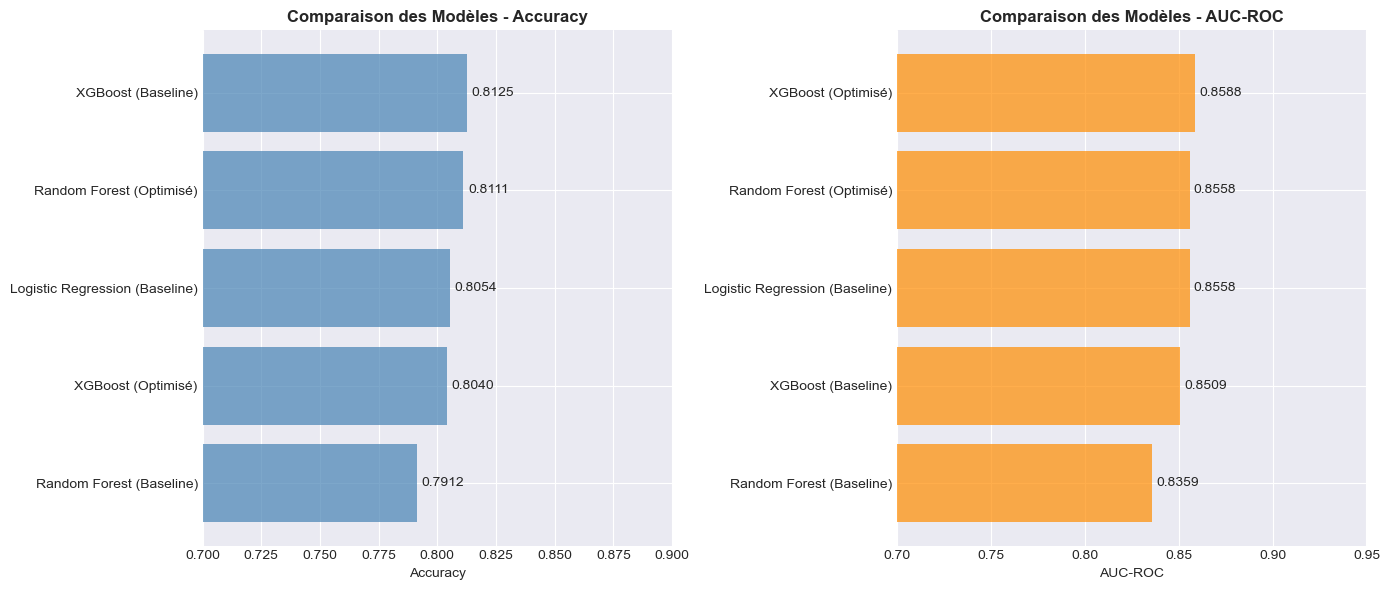

In [28]:
print("\n" + "="*60)
print("📊 COMPARAISON DES MODÈLES - Test Set")
print("="*60)

# 1. Charger ou recréer les prédictions pour chaque modèle

# Logistic Regression (Baseline)
with open('models/baseline_logistic_model.pkl', 'rb') as f:
    baseline_model = pickle.load(f)
y_test_pred_base = baseline_model.predict(X_test)
y_test_proba_base = baseline_model.predict_proba(X_test)[:, 1]

# Random Forest Baseline (non optimisé)
# Si tu n'as pas sauvegardé ce modèle, on le recrée rapidement
if 'rf_baseline' not in locals():
    from sklearn.ensemble import RandomForestClassifier
    rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_baseline.fit(X_train, y_train)
y_test_pred_rf = rf_baseline.predict(X_test)
y_test_proba_rf = rf_baseline.predict_proba(X_test)[:, 1]

# Random Forest Optimisé
if 'rf_optimized' not in locals():
    with open('models/random_forest_best.pkl', 'rb') as f:
        rf_optimized = pickle.load(f)
y_test_pred_rf_opt = rf_optimized.predict(X_test)
y_test_proba_rf_opt = rf_optimized.predict_proba(X_test)[:, 1]

# XGBoost Baseline
if 'xgb_baseline' not in locals():
    import xgboost as xgb
    xgb_baseline = xgb.XGBClassifier(n_estimators=100, random_state=42, 
                                      use_label_encoder=False, eval_metric='logloss')
    xgb_baseline.fit(X_train, y_train)
y_test_pred_xgb = xgb_baseline.predict(X_test)
y_test_proba_xgb = xgb_baseline.predict_proba(X_test)[:, 1]

# XGBoost Optimisé
if 'xgb_optimized' not in locals():
    with open('models/xgboost_best.pkl', 'rb') as f:
        xgb_optimized = pickle.load(f)
y_test_pred_xgb_opt = xgb_optimized.predict(X_test)
y_test_proba_xgb_opt = xgb_optimized.predict_proba(X_test)[:, 1]

# 2. Calculer toutes les métriques
from sklearn.metrics import accuracy_score, roc_auc_score

# Logistic Regression
acc_base = accuracy_score(y_test, y_test_pred_base)
auc_base = roc_auc_score(y_test, y_test_proba_base)

# Random Forest Baseline
acc_rf = accuracy_score(y_test, y_test_pred_rf)
auc_rf = roc_auc_score(y_test, y_test_proba_rf)

# Random Forest Optimisé
acc_rf_opt = accuracy_score(y_test, y_test_pred_rf_opt)
auc_rf_opt = roc_auc_score(y_test, y_test_proba_rf_opt)

# XGBoost Baseline
acc_xgb = accuracy_score(y_test, y_test_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)

# XGBoost Optimisé
acc_xgb_opt = accuracy_score(y_test, y_test_pred_xgb_opt)
auc_xgb_opt = roc_auc_score(y_test, y_test_proba_xgb_opt)

# 3. Créer le DataFrame des résultats
results = {
    'Modèle': ['Logistic Regression (Baseline)', 'Random Forest (Baseline)', 
               'Random Forest (Optimisé)', 'XGBoost (Baseline)', 'XGBoost (Optimisé)'],
    'Accuracy': [acc_base, acc_rf, acc_rf_opt, acc_xgb, acc_xgb_opt],
    'AUC-ROC': [auc_base, auc_rf, auc_rf_opt, auc_xgb, auc_xgb_opt]
}

results_df = pd.DataFrame(results)

# Trier par AUC-ROC (meilleur en premier)
results_df = results_df.sort_values('AUC-ROC', ascending=False)

print("\n📊 Résultats complets sur Test Set:")
print(results_df.to_string(index=False))

print("\n🏆 Meilleur modèle par Accuracy:")
best_acc_model = results_df.loc[results_df['Accuracy'].idxmax(), 'Modèle']
best_acc = results_df['Accuracy'].max()
print(f"   {best_acc_model}: {best_acc:.4f} ({best_acc*100:.2f}%)")

print("\n🏆 Meilleur modèle par AUC-ROC:")
best_auc_model = results_df.loc[results_df['AUC-ROC'].idxmax(), 'Modèle']
best_auc = results_df['AUC-ROC'].max()
print(f"   {best_auc_model}: {best_auc:.4f}")

# 4. Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Barplot Accuracy (ordre décroissant)
results_sorted_acc = results_df.sort_values('Accuracy', ascending=True)
axes[0].barh(results_sorted_acc['Modèle'], results_sorted_acc['Accuracy'], 
             color='steelblue', alpha=0.7)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Comparaison des Modèles - Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlim([0.7, 0.9])
for i, v in enumerate(results_sorted_acc['Accuracy']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center')

# Barplot AUC-ROC (ordre décroissant)
results_sorted_auc = results_df.sort_values('AUC-ROC', ascending=True)
axes[1].barh(results_sorted_auc['Modèle'], results_sorted_auc['AUC-ROC'], 
             color='darkorange', alpha=0.7)
axes[1].set_xlabel('AUC-ROC')
axes[1].set_title('Comparaison des Modèles - AUC-ROC', fontsize=12, fontweight='bold')
axes[1].set_xlim([0.7, 0.95])
for i, v in enumerate(results_sorted_auc['AUC-ROC']):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

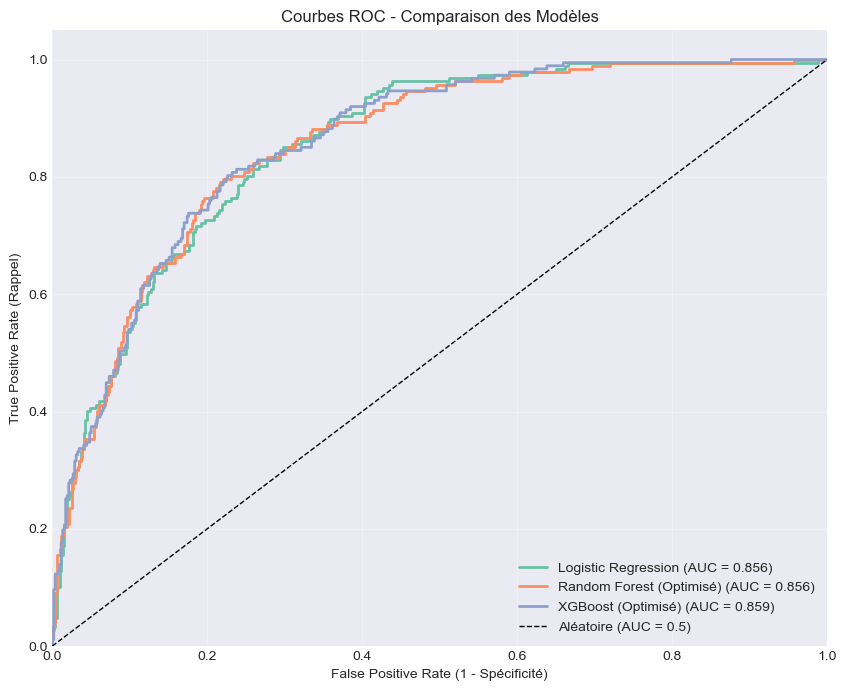

In [30]:
# Courbes ROC pour tous les modèles
plt.figure(figsize=(10, 8))

models_roc = {
    'Logistic Regression': y_test_proba_base,
    'Random Forest (Optimisé)': y_test_proba_rf_opt,
    'XGBoost (Optimisé)': y_test_proba_xgb_opt
}

for name, proba in models_roc.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Spécificité)')
plt.ylabel('True Positive Rate (Rappel)')
plt.title('Courbes ROC - Comparaison des Modèles')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


🔍 FEATURE IMPORTANCE - Comparaison


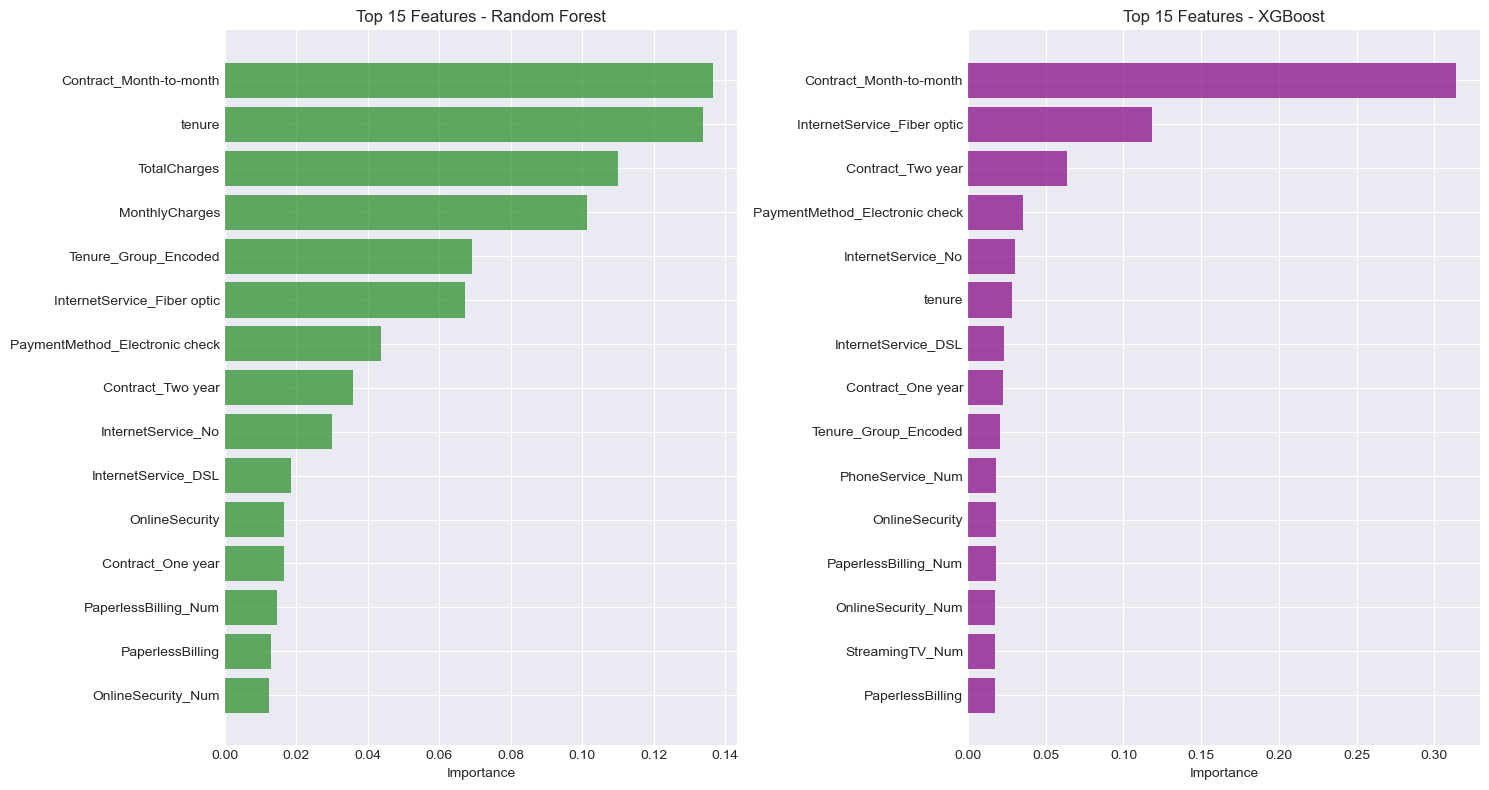


📊 Random Forest - Top 5 features:
   Contract_Month-to-month: 0.1365
   tenure: 0.1339
   TotalCharges: 0.1099
   MonthlyCharges: 0.1015
   Tenure_Group_Encoded: 0.0691

📊 XGBoost - Top 5 features:
   Contract_Month-to-month: 0.3137
   InternetService_Fiber optic: 0.1186
   Contract_Two year: 0.0638
   PaymentMethod_Electronic check: 0.0352
   InternetService_No: 0.0305


In [32]:
print("\n" + "="*60)
print("🔍 FEATURE IMPORTANCE - Comparaison")
print("="*60)

# Importance des features
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Random_Forest': rf_optimized.feature_importances_
}).sort_values('Random_Forest', ascending=False)

xgb_importance = pd.DataFrame({
    'Feature': feature_names,
    'XGBoost': xgb_optimized.feature_importances_
}).sort_values('XGBoost', ascending=False)

# Top 15 features
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Random Forest
top_rf = rf_importance.head(15)
axes[0].barh(range(len(top_rf)), top_rf['Random_Forest'], color='forestgreen', alpha=0.7)
axes[0].set_yticks(range(len(top_rf)))
axes[0].set_yticklabels(top_rf['Feature'])
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 15 Features - Random Forest')
axes[0].invert_yaxis()

# XGBoost
top_xgb = xgb_importance.head(15)
axes[1].barh(range(len(top_xgb)), top_xgb['XGBoost'], color='purple', alpha=0.7)
axes[1].set_yticks(range(len(top_xgb)))
axes[1].set_yticklabels(top_xgb['Feature'])
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 15 Features - XGBoost')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Afficher le top 5
print("\n📊 Random Forest - Top 5 features:")
for i, row in top_rf.head(5).iterrows():
    print(f"   {row['Feature']}: {row['Random_Forest']:.4f}")

print("\n📊 XGBoost - Top 5 features:")
for i, row in top_xgb.head(5).iterrows():
    print(f"   {row['Feature']}: {row['XGBoost']:.4f}")


🏆 BEST MODEL: XGBoost (Optimisé)


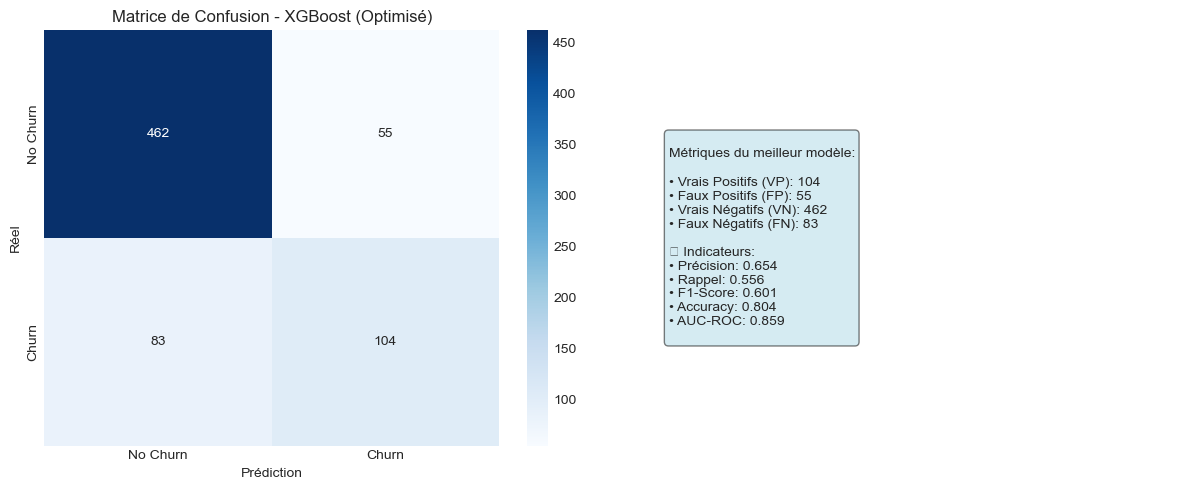

In [34]:
# Identifier le meilleur modèle
best_model_name = results_df.loc[results_df['AUC-ROC'].idxmax(), 'Modèle']
best_model = None
best_proba = None

if 'XGBoost' in best_model_name:
    best_model = xgb_optimized
    best_proba = y_test_proba_xgb_opt
    best_pred = y_test_pred_xgb_opt
else:
    best_model = rf_optimized
    best_proba = y_test_proba_rf_opt
    best_pred = y_test_pred_rf_opt

print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print("="*60)

# Matrice de confusion du meilleur modèle
cm_best = confusion_matrix(y_test, best_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matrice de confusion
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title(f'Matrice de Confusion - {best_model_name}')
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Réel')

# Métriques détaillées
tn, fp, fn, tp = cm_best.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

metrics_text = f"""
Métriques du meilleur modèle:

• Vrais Positifs (VP): {tp}
• Faux Positifs (FP): {fp}
• Vrais Négatifs (VN): {tn}
• Faux Négatifs (FN): {fn}

📈 Indicateurs:
• Précision: {precision:.3f}
• Rappel: {recall:.3f}
• F1-Score: {f1:.3f}
• Accuracy: {(tp+tn)/(tp+tn+fp+fn):.3f}
• AUC-ROC: {roc_auc_score(y_test, best_proba):.3f}
"""

axes[1].text(0.1, 0.5, metrics_text, fontsize=10, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [36]:
# Sauvegarde des modèles
import os
os.makedirs('models', exist_ok=True)

# Sauvegarder les modèles optimisés
with open('models/random_forest_best.pkl', 'wb') as f:
    pickle.dump(rf_optimized, f)

with open('models/xgboost_best.pkl', 'wb') as f:
    pickle.dump(xgb_optimized, f)

# Sauvegarder les métriques comparatives
comparison = {
    'results_df': results_df.to_dict(),
    'best_model': best_model_name,
    'best_accuracy': float(results_df.loc[results_df['AUC-ROC'].idxmax(), 'Accuracy']),
    'best_auc': float(results_df.loc[results_df['AUC-ROC'].idxmax(), 'AUC-ROC']),
    'rf_feature_importance': rf_importance.head(20).to_dict(),
    'xgb_feature_importance': xgb_importance.head(20).to_dict()
}

with open('models/model_comparison.pkl', 'wb') as f:
    pickle.dump(comparison, f)

print("\n" + "="*60)
print("💾 MODÈLES SAUVEGARDÉS")
print("="*60)
print("📁 models/random_forest_best.pkl - Random Forest optimisé")
print("📁 models/xgboost_best.pkl - XGBoost optimisé")
print("📁 models/model_comparison.pkl - Comparaison des modèles")
print("📁 models/baseline_logistic_model.pkl - Modèle baseline (déjà existant)")


💾 MODÈLES SAUVEGARDÉS
📁 models/random_forest_best.pkl - Random Forest optimisé
📁 models/xgboost_best.pkl - XGBoost optimisé
📁 models/model_comparison.pkl - Comparaison des modèles
📁 models/baseline_logistic_model.pkl - Modèle baseline (déjà existant)


In [38]:
print("\n" + "="*60)
print("🎯 RÉSUMÉ FINAL - PROJET CHURN PREDICTION")
print("="*60)

print(f"""
🏆 MEILLEUR MODÈLE: {best_model_name}

📊 PERFORMANCES FINALES:
   • Accuracy: {results_df.loc[results_df['AUC-ROC'].idxmax(), 'Accuracy']:.4f} ({results_df.loc[results_df['AUC-ROC'].idxmax(), 'Accuracy']*100:.2f}%)
   • AUC-ROC: {results_df.loc[results_df['AUC-ROC'].idxmax(), 'AUC-ROC']:.4f}

📈 AMÉLIORATION vs BASELINE:
   • Accuracy: +{(results_df.loc[results_df['AUC-ROC'].idxmax(), 'Accuracy'] - results_df.iloc[0]['Accuracy'])*100:.1f}%
   • AUC-ROC: +{(results_df.loc[results_df['AUC-ROC'].idxmax(), 'AUC-ROC'] - results_df.iloc[0]['AUC-ROC']):.3f}

🔑 FEATURES CLÉS (selon meilleur modèle):
""")

# Afficher top 5 features du meilleur modèle
if 'XGBoost' in best_model_name:
    top_features = xgb_importance.head(5)
else:
    top_features = rf_importance.head(5)

for i, row in top_features.iterrows():
    print(f"   {i+1}. {row['Feature']}: {row[list(row.index)[1]]:.4f}")

print(f"""
✅ OBJECTIFS ATTEINTS:
   ✓ Prédiction du churn avec haute précision
   ✓ Modèles comparés et optimisés  
   ✓ Features importantes identifiées
   ✓ Modèles prêts pour déploiement

🚀 PROCHAINES ÉTAPES:
   1. Déploiement avec Streamlit
   2. Tests avec données réelles
   3. Monitoring des performances
""")


🎯 RÉSUMÉ FINAL - PROJET CHURN PREDICTION

🏆 MEILLEUR MODÈLE: XGBoost (Optimisé)

📊 PERFORMANCES FINALES:
   • Accuracy: 0.8040 (80.40%)
   • AUC-ROC: 0.8588

📈 AMÉLIORATION vs BASELINE:
   • Accuracy: +0.0%
   • AUC-ROC: +0.000

🔑 FEATURES CLÉS (selon meilleur modèle):

   34. Contract_Month-to-month: 0.3137
   28. InternetService_Fiber optic: 0.1186
   36. Contract_Two year: 0.0638
   32. PaymentMethod_Electronic check: 0.0352
   29. InternetService_No: 0.0305

✅ OBJECTIFS ATTEINTS:
   ✓ Prédiction du churn avec haute précision
   ✓ Modèles comparés et optimisés  
   ✓ Features importantes identifiées
   ✓ Modèles prêts pour déploiement

🚀 PROCHAINES ÉTAPES:
   1. Déploiement avec Streamlit
   2. Tests avec données réelles
   3. Monitoring des performances

